# Regression and Hyperparameter Tuning with Keras Tuner

It is highly recommended to use a powerful **GPU**, you can use it for free uploading this notebook to [Google Colab](https://colab.research.google.com/notebooks/intro.ipynb).
<table align="center">
 <td align="center"><a target="_blank" href="https://colab.research.google.com/github/ezponda/intro_deep_learning/blob/main/class/Fundamentals/Regression_tuner.ipynb">
        <img src="https://colab.research.google.com/img/colab_favicon_256px.png"  width="50" height="50" style="padding-bottom:5px;" />Run in Google Colab</a></td>
  <td align="center"><a target="_blank" href="https://github.com/ezponda/intro_deep_learning/blob/main/class/Fundamentals/Regression_tuner.ipynb">
        <img src="https://github.githubassets.com/images/modules/logos_page/GitHub-Mark.png"  width="50" height="50" style="padding-bottom:5px;" />View Source on GitHub</a></td>
</table>

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
tf.keras.utils.set_random_seed(0)

def plot_history(history: tf.keras.callbacks.History) -> None:
    """Plot training and validation loss/metrics curves."""
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    # Check if mae is available
    has_mae = 'mae' in hist.columns
    n_plots = 2 if has_mae else 1

    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    # Loss plot
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (MSE)')
    axes[0].plot(hist['epoch'], hist['loss'], label='Train')
    axes[0].plot(hist['epoch'], hist['val_loss'], label='Validation')
    axes[0].legend()
    axes[0].grid(True)

    # MAE plot (if available)
    if has_mae:
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('MAE')
        axes[1].plot(hist['epoch'], hist['mae'], label='Train')
        axes[1].plot(hist['epoch'], hist['val_mae'], label='Validation')
        axes[1].legend()
        axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# Abalone Dataset

Abalones are marine snails that can be found along coasts of almost every continent.

<img src="https://raw.githubusercontent.com/ezponda/intro_deep_learning/main/images/abalone.jpg" alt="abalone" border="0" width="400" height="500">



In this notebook we are going to Predict the age of abalone from physical measurements. [Link to documentation](https://archive.ics.uci.edu/ml/datasets/abalone).

In [3]:
df_train = pd.read_csv(
    "https://storage.googleapis.com/download.tensorflow.org/data/abalone_train.csv",
    names=["Length", "Diameter", "Height", "Whole weight", "Shucked weight",
           "Viscera weight", "Shell weight", "Age"])
df_train.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Age
0,0.435,0.335,0.110,0.334,0.1355,0.0775,0.0965,7
1,0.585,0.450,0.125,0.874,0.3545,0.2075,0.2250,6
2,0.655,0.510,0.160,1.092,0.3960,0.2825,0.3700,14
3,0.545,0.425,0.125,0.768,0.2940,0.1495,0.2600,16
4,0.545,0.420,0.130,0.879,0.3740,0.1695,0.2300,13


In [4]:
df_train.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Age
count,3320.000000,3320.000000,3320.000000,3320.000000,3320.000000,3320.000000,3320.000000,3320.000000
mean,0.522693,0.406575,0.139271,0.824734,0.357705,0.180162,0.237921,9.896988
std,0.121164,0.100120,0.042708,0.491182,0.222223,0.110182,0.140261,3.205654
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.345000,0.115000,0.436375,0.181500,0.092000,0.127375,8.000000
50%,0.540000,0.425000,0.140000,0.795250,0.335500,0.170750,0.230000,9.000000
75%,0.615000,0.480000,0.165000,1.150000,0.504500,0.253125,0.325000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,27.000000


In [5]:
y_train = df_train.pop('Age')
X_train = df_train.copy()

In [6]:
df_test = pd.read_csv(
    "https://storage.googleapis.com/download.tensorflow.org/data/abalone_test.csv",
    names=["Length", "Diameter", "Height", "Whole weight", "Shucked weight",
           "Viscera weight", "Shell weight", "Age"])
y_test = df_test.pop('Age')
X_test = df_test.copy()

In [ ]:
print(f'X_train shape: {X_train.shape}, X_test shape: {X_test.shape}')

## Regression Losses

- **Mean Squared Error (MSE)**:

```python
tf.keras.losses.MSE
```
```python
model.compile(loss='mse') or model.compile(loss=tf.keras.losses.MSE)
```

$$ \mathrm{MSE} = \frac{\sum_{i=1}^n\left( y_i - \hat{y_i}\right)^2}{n}$$


- **Mean Absolute Error (MAE)**:

```python
tf.keras.losses.MAE
```
```python
model.compile(loss='mae') or model.compile(loss=tf.keras.losses.MAE)
```

$$ \mathrm{MAE} = \frac{\sum_{i=1}^n\left| y_i - \hat{y_i}\right|}{n}$$


## Question 1: Create a net with at least 1 hidden layer


1. You can use the [Functional API](https://keras.io/guides/functional_api/):

You need to start with an input data entry:
```python    
    inputs = keras.Input(shape=(...,))
    layer_1 = layers.Dense(...)(inputs)
```

and the network outputs:
```python
outputs = layers.Dense(...)(previous_layer)
model = keras.Model(inputs=inputs, outputs=outputs)
```

2. Or you can use [Sequential API](https://keras.io/guides/sequential_model/)

```python
model = keras.Sequential(name='example_model')
model.add(layers.Dense(..., input_shape=(8,))
model.add(...
```

You can introduce regularization methods seen in [Prevent_Overfitting.ipynb](https://github.com/ezponda/intro_deep_learning/blob/main/class/Fundamentals/Prevent_Overfitting.ipynb) like [Dropout layer](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout):


```python
tf.keras.layers.Dropout(
    rate, noise_shape=None, seed=None, **kwargs
)
```

With Functional API:
```python
next_layer = layers.Dropout(0.4)(prev_layer)
```
With Sequential:
```python
model.add(layers.Dropout(0.4))


In [ ]:
model = keras.Sequential()

model.add(layers.Dense(..., input_shape=(...,), activation=...))
...
# output layer
model.add(layers.Dense(..., activation=...))

## model summary
model.summary()

In [ ]:
# Using the Functional API
# 1. Define the input layer
inputs = keras.Input(shape=(...,))

# 2. Build the hidden layers, You can also add dropout or other layer types
x = layers.Dense(..., activation=...)(inputs)
...
x = layers.Dropout(...)(x)
x = layers.Dense(..., activation=...)(x)

# 3. Define the output layer
outputs = layers.Dense(..., activation=...)(x)

# 4. Create the model by specifying inputs and outputs
model = keras.Model(inputs=..., outputs=..., name='functional_model')

# Model summary
model.summary()

[Early stopping callback](https://keras.io/api/callbacks/early_stopping/)

In [ ]:
# Early stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor=...,
    patience=...,
    min_delta=...,
    restore_best_weights=...,
)

In [ ]:
model.compile(
    optimizer='adam',
    loss=...,
    metrics=[...],
)
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    callbacks=...,  # early stopping
    )

In [ ]:
plot_history(history)

In [ ]:
results = model.evaluate(X_test, y_test, verbose=1)
print('Test Loss: {}'.format(results[0]))

## Question 2: Normalize the inputs and train the same model

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)
print('X_train mu, sigma', X_train_norm.mean(0), X_train_norm.std(0))
print('X_test mu, sigma', X_test_norm.mean(0), X_test_norm.std(0))

X_train mu, sigma [ 2.77689518e-16  4.65491099e-17  2.50402109e-16 -2.81434849e-16
  2.18299274e-16  1.77100637e-16 -1.05404306e-16] [1. 1. 1. 1. 1. 1. 1.]
X_test mu, sigma [0.05808422 0.06917445 0.03098307 0.04461505 0.04160742 0.02421514
 0.03516632] [0.95187926 0.95135017 0.89294094 0.99223632 0.99454932 0.97495047
 0.96304109]


In [ ]:
model = keras.Sequential()

...
## model summary
model.summary()

In [ ]:
# Early stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor=...,
    patience=...,
    min_delta=...,
    restore_best_weights=...,
)

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.MSE,
    metrics=['mae']
)

model.fit(
    X_train_norm,
    y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    callbacks=...,  # early stoppings
    )

In [ ]:
results = model.evaluate(X_test_norm, y_test, verbose=1)
print('Test Loss: {}'.format(results[0]))

## Optimizers:

- [SGD](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD): Gradient descent with momentum
```python
tf.keras.optimizers.SGD(
    learning_rate=0.01, momentum=0.0, nesterov=False, name='SGD', **kwargs
)
```
If momentum is 0:
```python
w = w - learning_rate * gradient
```
If we have momentum:

 ```python
velocity = momentum * velocity - learning_rate * g
w = w + velocity
```


- [RMSprop](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/RMSprop): Root Mean Square Propagation
```python
tf.keras.optimizers.RMSprop(
    learning_rate=0.001, rho=0.9, momentum=0.0, epsilon=1e-07, centered=False,
    name='RMSprop', **kwargs
)
```
- [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam): Adaptive Moment Estimation,  is an update to the RMSProp algorithm
```python
tf.keras.optimizers.Adam(
    learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07, amsgrad=False,
    name='Adam', **kwargs
)
```

```python
model.compile(loss='mse', optimizer='adam')
model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
```

## Question 3: Train the same model with different optimizers

In [ ]:
model = keras.Sequential()
...
## model summary
model.summary()

In [ ]:
model.compile(
    optimizer=...,
    loss=...,
    metrics=[...]
)
model.fit(X_train_norm, y_train, epochs=50, validation_split=0.2, batch_size=32)

In [ ]:
results = model.evaluate(X_test_norm, y_test, verbose=1)
print('Test Loss: {}'.format(results[0]))

# Keras Tuner : Introduction to Hyperparameter Optimization

The [Keras Tuner](https://www.tensorflow.org/tutorials/keras/keras_tuner) is a library for hyper-parameter tuning.

## What is Hyperparameter Tuning?

Hyperparameter tuning is the process of finding the optimal set of hyperparameters for a machine learning model to maximize its performance. Unlike model parameters (weights and biases) that are learned during training, hyperparameters are set before the learning process begins and influence how the model learns.

Common hyperparameters include:
- **Model architecture**: number of layers, units per layer
- **Training parameters**: learning rate, batch size, dropout rate
- **Regularization**: L1/L2 penalties, early stopping criteria

Manual tuning of these parameters can be time-consuming and often leads to suboptimal results. Keras Tuner provides an automated approach to efficiently search the hyperparameter space.

## Understanding Different Tuning Strategies

Keras Tuner offers four main strategies for hyperparameter optimization:

### 1. RandomSearch
- **How it works**: Randomly samples from the hyperparameter space
- **Pros**: Simple, easily parallelizable, no assumptions about parameter importance
- **Cons**: Can be inefficient for large search spaces
- **Best for**: Initial exploration or when little is known about the hyperparameter landscape

### 2. Hyperband
- **How it works**: Allocates resources (epochs) dynamically, quickly discarding poor performers
- **Pros**: More efficient than random search, especially for deep networks
- **Cons**: More complex to configure correctly
- **Best for**: When training is computationally expensive and you want to balance exploration vs. exploitation

### 3. BayesianOptimization
- **How it works**: Builds a probability model of the objective function and uses it to select hyperparameters
- **Pros**: More efficient use of resources, learns from previous evaluations
- **Cons**: More complex, computationally intensive for each iteration
- **Best for**: When evaluation is expensive and you have a moderate search space

### 4. Sklearn
- **How it works**: Interface to scikit-learn's hyperparameter search methods
- **Pros**: Familiar API for those coming from scikit-learn
- **Cons**: Limited to sklearn's hyperparameter tuning capabilities
- **Best for**: When integrating with existing sklearn pipelines


In [10]:
!pip install -U keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.1 MB/s eta 0:00:00


In [11]:
import kerastuner as kt

/tmp/ipykernel_5220/1654478174.py:1: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


Hyperparameters are of two types:
1. **Model hyperparameters** like number of units, type of activation or number hidden layers.
2. **Algorithm hyperparameters** like the learning rate in adam.

The model-building function takes an argument `hp` from which you can sample hyper-parameters.

```python
def build_model(hp):
    ...
    return model

```

- `hp.Int` to sample an integer from a certain range:
```python
hp.Int('units', min_value=32, max_value=256, step=32, default=64)
```
- `hp.Float` to sample a float number from a certain range:
```python
hp.Float('dropout', min_value=0.0, max_value=0.1, default=0.005, step=0.05)
```
- `hp.Choice` to select values in a list:
```python
hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
```
- [list of hyperparameter methods](https://keras-team.github.io/keras-tuner/documentation/hyperparameters/)

In [12]:
def build_model(hp):
    model = keras.Sequential()
    # Sample different number of layers with hp.Int
    for i in range(hp.Int('num_layers', 1, 3)):
        # Sample different number of layers with hp.Int
        model.add(layers.Dense(units=hp.Int('units_' + str(i),
                                            min_value=64,
                                            max_value=128,
                                            step=32),
                               activation='relu'))
    # Sample different activation functions with hp.Choice
    model.add(layers.Dense(1, activation=hp.Choice('output_activation', ['relu', 'linear'])))

    # Sample different activation functions with hp.Choice
    model.compile(
        loss='mse',
        metrics=['mae'])
    return model

The Keras Tuner has four [tuners](https://keras-team.github.io/keras-tuner/documentation/tuners/) available  `RandomSearch`, `Hyperband`, `BayesianOptimization`, and `Sklearn`


In [16]:
'''
tuner = kt.Hyperband(build_model,
                     objective='val_loss',
                     max_epochs=15,
                     factor=3,
                     hyperband_iterations=1,
                     directory='my_dir',
                     project_name='intro_to_kt')
'''

tuner = kt.RandomSearch(build_model,
                     objective='val_loss',
                     max_trials=20,
                     directory='my_dir',
                     project_name='intro_to_kt')

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

In [17]:
tuner.search(X_train_norm, y_train, epochs=20, validation_split=0.15, batch_size=32, callbacks=[stop_early])

# Get the optimal hyperparameters
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hps.get_config())

Trial 20 Complete [00h 00m 09s]
val_loss: 4.940211296081543

Best val_loss So Far: 4.654630184173584
Total elapsed time: 00h 02m 57s
{'space': [{'class_name': 'Int', 'config': {'name': 'num_layers', 'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}}, {'class_name': 'Int', 'config': {'name': 'units_0', 'default': None, 'conditions': [], 'min_value': 64, 'max_value': 128, 'step': 32, 'sampling': 'linear'}}, {'class_name': 'Choice', 'config': {'name': 'output_activation', 'default': 'relu', 'conditions': [], 'values': ['relu', 'linear'], 'ordered': False}}, {'class_name': 'Int', 'config': {'name': 'units_1', 'default': None, 'conditions': [], 'min_value': 64, 'max_value': 128, 'step': 32, 'sampling': 'linear'}}, {'class_name': 'Int', 'config': {'name': 'units_2', 'default': None, 'conditions': [], 'min_value': 64, 'max_value': 128, 'step': 32, 'sampling': 'linear'}}], 'values': {'num_layers': 2, 'units_0': 128, 'output_activation': 'linear

In [18]:
tuner.results_summary()

Results summary
Results in my_dir/intro_to_kt
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 05 summary
Hyperparameters:
num_layers: 2
units_0: 128
output_activation: linear
units_1: 96
units_2: 64
Score: 4.654630184173584

Trial 17 summary
Hyperparameters:
num_layers: 2
units_0: 96
output_activation: linear
units_1: 128
units_2: 64
Score: 4.680206775665283

Trial 07 summary
Hyperparameters:
num_layers: 2
units_0: 128
output_activation: linear
units_1: 128
units_2: 128
Score: 4.694840908050537

Trial 03 summary
Hyperparameters:
num_layers: 2
units_0: 64
output_activation: linear
units_1: 96
Score: 4.711284637451172

Trial 08 summary
Hyperparameters:
num_layers: 2
units_0: 96
output_activation: linear
units_1: 96
units_2: 96
Score: 4.716734886169434

Trial 02 summary
Hyperparameters:
num_layers: 2
units_0: 64
output_activation: relu
units_1: 64
Score: 4.738584995269775

Trial 06 summary
Hyperparameters:
num_layers: 2
units_0: 64
output_activation: linear
units

In [19]:
print(f"Best output activation function: {best_hps.get('output_activation')}")
print(f"Best number of hidden layers: {best_hps.get('num_layers')}")
for i in range(best_hps.get('num_layers')):
    print(f"Number of units of hidden layer {i+1}: {best_hps.get('units_' + str(i))}")

Best output activation function: linear
Best number of hidden layers: 2
Number of units of hidden layer 1: 128
Number of units of hidden layer 2: 96


### Hyperparameter Importance

Extracting hyperparameter data from tuner...
Analyzed 20 trials

Top 10 configurations:

Rank 1 (Score: 4.6546):
  num_layers: 2
  output_activation: linear
  units_0: 128
  units_1: 96.0
  units_2: 64.0

Rank 2 (Score: 4.6802):
  num_layers: 2
  output_activation: linear
  units_0: 96
  units_1: 128.0
  units_2: 64.0

Rank 3 (Score: 4.6948):
  num_layers: 2
  output_activation: linear
  units_0: 128
  units_1: 128.0
  units_2: 128.0

Rank 4 (Score: 4.7113):
  num_layers: 2
  output_activation: linear
  units_0: 64
  units_1: 96.0
  units_2: nan

Rank 5 (Score: 4.7167):
  num_layers: 2
  output_activation: linear
  units_0: 96
  units_1: 96.0
  units_2: 96.0

Rank 6 (Score: 4.7386):
  num_layers: 2
  output_activation: relu
  units_0: 64
  units_1: 64.0
  units_2: nan

Rank 7 (Score: 4.7395):
  num_layers: 2
  output_activation: linear
  units_0: 64
  units_1: 96.0
  units_2: 128.0

Rank 8 (Score: 4.8774):
  num_layers: 3
  output_activation: linear
  units_0: 128
  units_1: 96.0
  uni

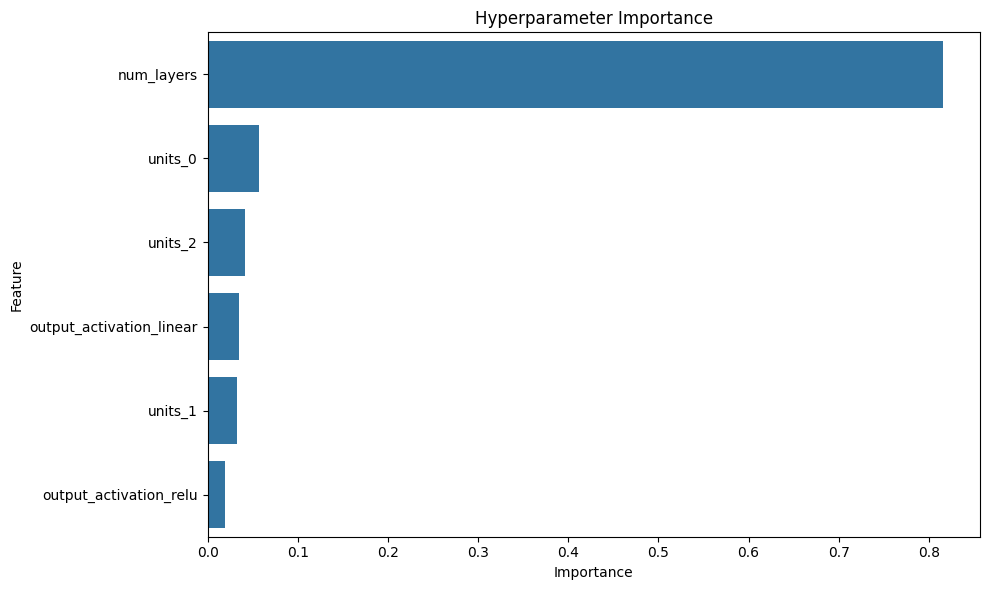


Hyperparameter importance ranking:
1. num_layers: 0.8159
2. units_0: 0.0568
3. units_2: 0.0420
4. output_activation_linear: 0.0344
5. units_1: 0.0322
6. output_activation_relu: 0.0188


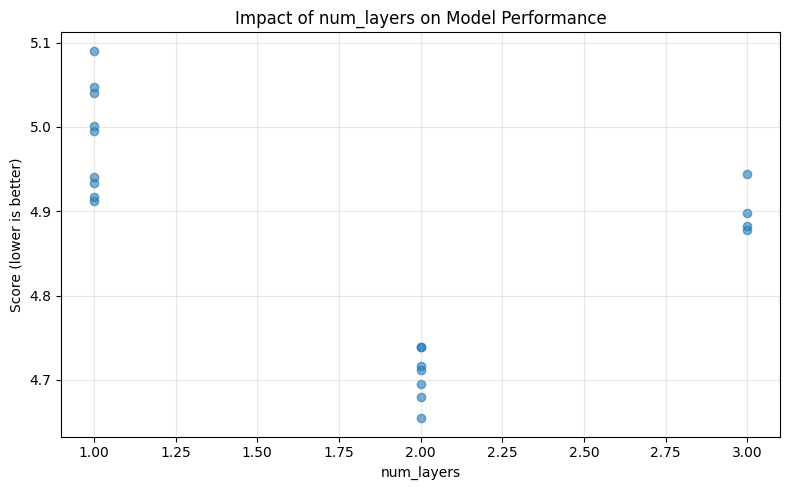


Analysis complete. Use these insights to refine your hyperparameter search!


In [22]:
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns

def analyze_hyperparameter_importance(tuner, top_n=10):
    """
    Analyze the importance of different hyperparameters using Random Forest.

    Parameters:
    -----------
    tuner : keras_tuner.Tuner
        The tuner object after running a hyperparameter search
    top_n : int, default=10
        Number of top trials to print

    Returns:
    --------
    importance_df : pandas.DataFrame
        DataFrame containing the importance of each hyperparameter
    """
    print("Extracting hyperparameter data from tuner...")

    # Extract hyperparameters and scores from tuner
    hp_results = []

    for trial_id, trial in tuner.oracle.trials.items():
        if trial.score is not None:  # Only include completed trials
            # Get hyperparameters
            hp_values = trial.hyperparameters.values
            # Add score (lower is better for loss)
            hp_values['score'] = trial.score
            hp_results.append(hp_values)

    # Convert to DataFrame
    results_df = pd.DataFrame(hp_results)

    # Show basic stats
    print(f"Analyzed {len(results_df)} trials")
    print("\nTop {top_n} configurations:".format(top_n=top_n))
    top_configs = results_df.sort_values('score').head(top_n)
    for i, (_, config) in enumerate(top_configs.iterrows()):
        print(f"\nRank {i+1} (Score: {config['score']:.4f}):")
        for param, value in sorted(config.items()):
            if param != 'score':
                print(f"  {param}: {value}")

    # Prepare data for Random Forest
    X = results_df.drop('score', axis=1)

    # Convert non-numeric columns to numeric
    for col in X.columns:
        if X[col].dtype == 'object':
            # Create dummies for categorical variables
            dummies = pd.get_dummies(X[col], prefix=col)
            X = pd.concat([X.drop(col, axis=1), dummies], axis=1)

    y = results_df['score']

    # Train Random Forest for feature importance
    print("\nTraining Random Forest to analyze hyperparameter importance...")
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X, y)

    # Get feature importance
    importance = rf.feature_importances_

    # Create DataFrame of features and importance
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance
    }).sort_values('Importance', ascending=False)

    # Plot feature importance
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
    plt.title('Hyperparameter Importance')
    plt.tight_layout()
    plt.show()

    # Print importance values
    print("\nHyperparameter importance ranking:")
    for i, (_, row) in enumerate(importance_df.iterrows()):
        if i < 15:  # Print top 15
            print(f"{i+1}. {row['Feature']}: {row['Importance']:.4f}")

    # Analyze top feature's impact with partial dependence plot
    top_feature = importance_df.iloc[0]['Feature']
    if top_feature in X.columns:  # Ensure it's a numeric feature
        plt.figure(figsize=(8, 5))
        plt.scatter(X[top_feature], y, alpha=0.6)
        plt.title(f'Impact of {top_feature} on Model Performance')
        plt.xlabel(top_feature)
        plt.ylabel('Score (lower is better)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    print("\nAnalysis complete. Use these insights to refine your hyperparameter search!")

    return importance_df


# After running tuner.search():
importance_df = analyze_hyperparameter_importance(tuner)

## Train the model

In [23]:
model = tuner.hypermodel.build(best_hps)
history = model.fit(X_train_norm, y_train, epochs=50, validation_split=0.15, callbacks=[stop_early])

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 40.3493 - mae: 5.0755 - val_loss: 14.1898 - val_mae: 2.9040
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.2826 - mae: 2.0376 - val_loss: 6.4366 - val_mae: 1.8594
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.6672 - mae: 1.7562 - val_loss: 5.7306 - val_mae: 1.7279
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6943 - mae: 1.6717 - val_loss: 5.3608 - val_mae: 1.6543
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0584 - mae: 1.6260 - val_loss: 5.1676 - val_mae: 1.6145
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.6096 - mae: 1.5993 - val_loss: 5.0494 - val_mae: 1.5911
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.2874 - mae: 1.5826 - val_loss: 4.9733 - val_mae: 1.5798
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.0637 - mae: 1.5706 - val_loss: 4.9226 - val_mae: 1.5712
Epoch 9/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.8844 - ma

In [24]:
results = model.evaluate(X_test_norm, y_test, verbose=1)
print('Test Loss: {}'.format(results[0]))

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.1660 - mae: 1.5336 
Test Loss: 5.166049480438232


## Question 4: Try to search with dropout

In [25]:
def build_model(hp):
    """Build a model with tunable architecture and dropout regularization."""
    model = keras.Sequential()

    # Tune the number of layers (try 1-4 layers)
    for i in range(hp.Int('num_layers', min_value=1, max_value=6)):
        # Tune the number of units in each layer
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=30, max_value=300, step=30),
            activation=hp.Choice(f'activation_{i}', values=['linear','relu'])
        ))

        # Add dropout after the dense layer
        model.add(layers.Dropout(
            hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.6, step=0.1)
        ))

    # Output layer for regression
    model.add(layers.Dense(1, activation='linear'))

    # Compile the model
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model

In [26]:
tuner = kt.Hyperband(build_model,
                     objective='val_loss',
                     max_epochs=15,
                     factor=3,
                     hyperband_iterations=1,
                     directory='my_dir_2',
                     project_name='intro_to_kt')

stop_early = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    )
tuner.search(X_train_norm, y_train, epochs=20, validation_split=0.15,
             batch_size=32, callbacks=[stop_early])

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hps.get_config())

Trial 30 Complete [00h 00m 10s]
val_loss: 5.058939456939697

Best val_loss So Far: 4.7914323806762695
Total elapsed time: 00h 03m 16s
{'space': [{'class_name': 'Int', 'config': {'name': 'num_layers', 'default': None, 'conditions': [], 'min_value': 1, 'max_value': 6, 'step': 1, 'sampling': 'linear'}}, {'class_name': 'Int', 'config': {'name': 'units_0', 'default': None, 'conditions': [], 'min_value': 30, 'max_value': 300, 'step': 30, 'sampling': 'linear'}}, {'class_name': 'Choice', 'config': {'name': 'activation_0', 'default': 'linear', 'conditions': [], 'values': ['linear', 'relu'], 'ordered': False}}, {'class_name': 'Float', 'config': {'name': 'dropout_0', 'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.6, 'step': 0.1, 'sampling': 'linear'}}, {'class_name': 'Int', 'config': {'name': 'units_1', 'default': None, 'conditions': [], 'min_value': 30, 'max_value': 300, 'step': 30, 'sampling': 'linear'}}, {'class_name': 'Choice', 'config': {'name': 'activation_1', 'default':

In [27]:
print(f"Best number of hidden layers: {best_hps.get('num_layers')}")
for i in range(best_hps.get('num_layers')):
    print(f"  Layer {i+1} - units: {best_hps.get('units_' + str(i))}, dropout: {best_hps.get('dropout_' + str(i))}")

Best number of hidden layers: 4
  Layer 1 - units: 180, dropout: 0.1
  Layer 2 - units: 60, dropout: 0.1
  Layer 3 - units: 300, dropout: 0.30000000000000004
  Layer 4 - units: 270, dropout: 0.4


In [28]:
model = tuner.hypermodel.build(best_hps)
history = model.fit(X_train_norm, y_train, epochs=50, validation_split=0.15, callbacks=[stop_early])

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 30.8252 - mae: 3.7930 - val_loss: 6.7928 - val_mae: 1.9442
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.1795 - mae: 1.9973 - val_loss: 5.8798 - val_mae: 1.7947
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7219 - mae: 1.8842 - val_loss: 5.1864 - val_mae: 1.6222
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2797 - mae: 1.7859 - val_loss: 4.9591 - val_mae: 1.6331
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.8415 - mae: 1.7762 - val_loss: 5.1980 - val_mae: 1.5815
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.7541 - mae: 1.7523 - val_loss: 5.1833 - val_mae: 1.5612
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.5388 - mae: 1.7263 - val_loss: 4.9039 - val_mae: 1.5366
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.6087 - mae: 1.7293 - val_loss: 4.9630 - val_mae: 1.5493
Epoch 9/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.4851 - mae:

In [29]:
results = model.evaluate(X_test_norm, y_test, verbose=1)
print('Test Loss: {}'.format(results[0]))

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.4786 - mae: 1.5320
Test Loss: 5.478577613830566


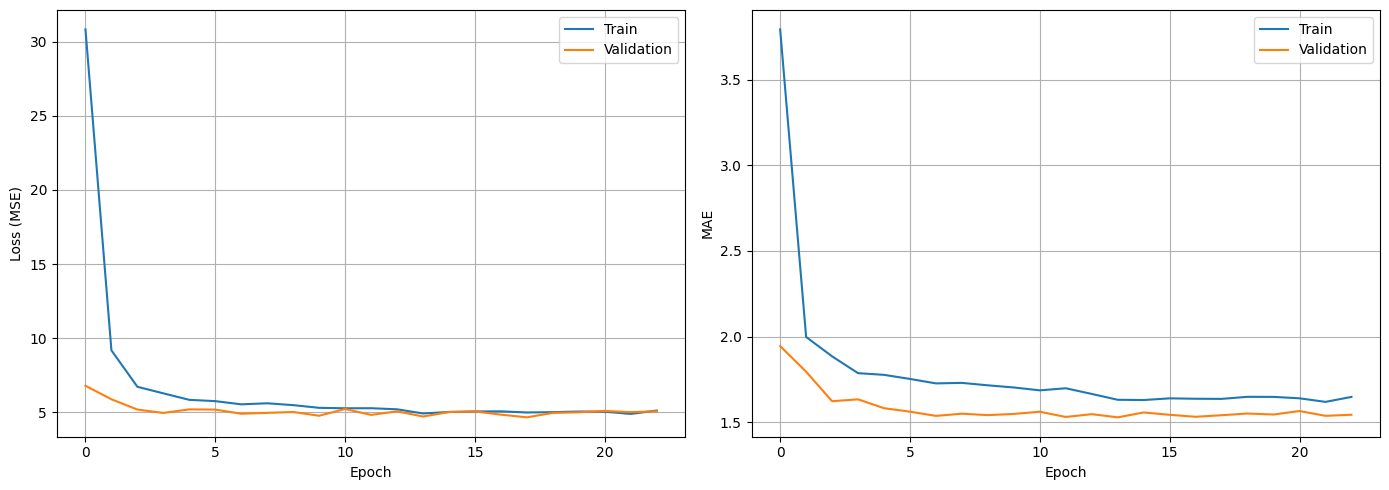

In [30]:
plot_history(history)